# Introdução ao Aprendizado Supervisionado


In [43]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error

In [44]:
df = pd.DataFrame({
    "A": 3,
    "B": pd.Timestamp("20240101"),
    "C": pd.Series(2, index=list(range(4)), dtype="float32"),
    "D": np.array([5] * 4, dtype="int32"),
    "E": pd.Categorical(["train", "test", "test", "train"]),
    "F": "foo"
})

In [45]:
df

,A,B,C,D,E,F
0,3,2024-01-01,2.0,5,train,foo
1,3,2024-01-01,2.0,5,test,foo
2,3,2024-01-01,2.0,5,test,foo
3,3,2024-01-01,2.0,5,train,foo


In [46]:
from sklearn import datasets

In [47]:
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [48]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["target_name"] = iris.target_names[df["target"]]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Axes: >

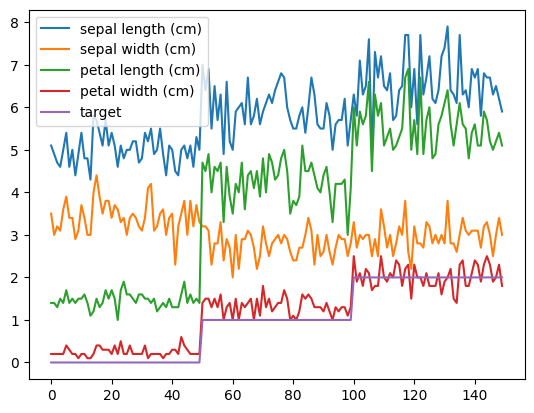

In [49]:
df.plot()

<Axes: ylabel='Frequency'>

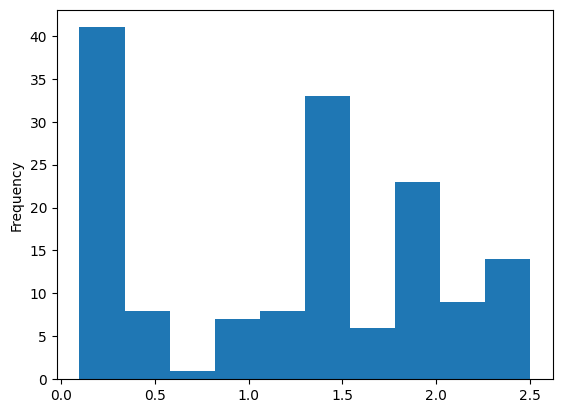

In [50]:
df['petal width (cm)'].plot.hist()

In [51]:
df['petal width (cm)'].unique()

array([0.2, 0.4, 0.3, 0.1, 0.5, 0.6, 1.4, 1.5, 1.3, 1.6, 1. , 1.1, 1.8,
       1.2, 1.7, 2.5, 1.9, 2.1, 2.2, 2. , 2.4, 2.3])

In [52]:
df[df['petal width (cm)'] == 1.1]
df.query("`petal width (cm)` == 1.1")


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
69,5.6,2.5,3.9,1.1,1,versicolor
80,5.5,2.4,3.8,1.1,1,versicolor
98,5.1,2.5,3.0,1.1,1,versicolor


In [53]:
# df.query("`petal width (cm)` > 1.1 & `petal width (cm)` < 1.4")
df[(df['petal width (cm)'] > 1.1) & (df['petal width (cm)'] < 1.4)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
53,5.5,2.3,4.0,1.3,1,versicolor
55,5.7,2.8,4.5,1.3,1,versicolor
58,6.6,2.9,4.6,1.3,1,versicolor
64,5.6,2.9,3.6,1.3,1,versicolor
71,6.1,2.8,4.0,1.3,1,versicolor
73,6.1,2.8,4.7,1.2,1,versicolor
74,6.4,2.9,4.3,1.3,1,versicolor
82,5.8,2.7,3.9,1.2,1,versicolor
87,6.3,2.3,4.4,1.3,1,versicolor
88,5.6,3.0,4.1,1.3,1,versicolor


In [54]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


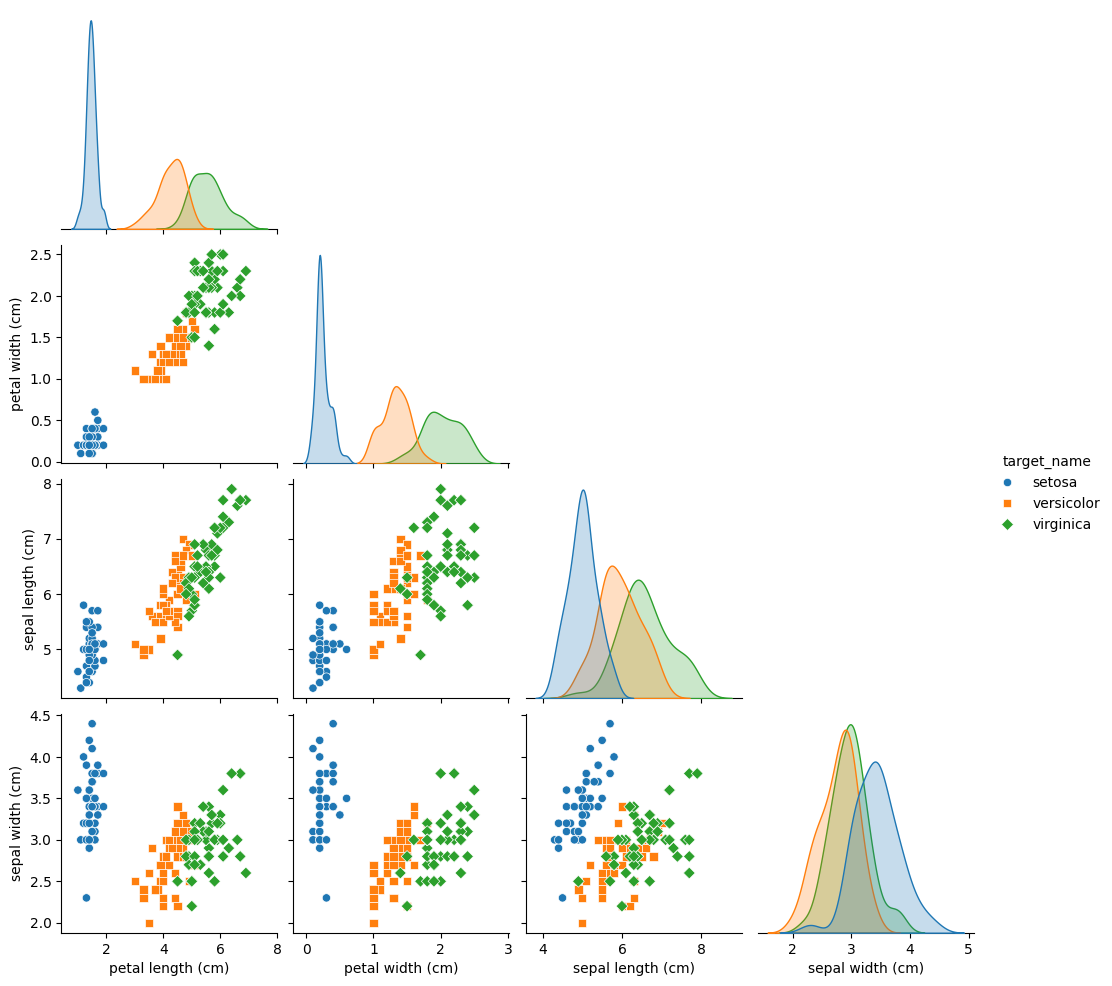

In [60]:
sns.pairplot(df[['petal length (cm)','petal width (cm)', 'sepal length (cm)', 'sepal width (cm)','target_name']], hue="target_name", markers=["o", "s", "D"], corner=True)